### Authenticate `gcloud` for `gsutil` access


In [ ]:
import sys, platform, importlib
from google.colab import auth

auth.authenticate_user(project_id="cs131-team04-sec1")

PROJECT_ID = "cs131-team04-sec1"
BUCKET_NAME = "datascrapers-team04"
BUCKET_URI = f"gs://{BUCKET_NAME}"

!gcloud config set project cs131-team04-sec1
!gsutil ls $BUCKET_URI
!gsutil cp $BUCKET_URI/Health_and_Personal_Care.jsonl.gz .
!gsutil cp $BUCKET_URI/meta_Health_and_Personal_Care.jsonl.gz .

!pip install -q pyspark

print("Python:", sys.version)
print("Platform:", platform.platform())

[environment: untagged] Read more to tag: g.co/cloud/project-env-tag.
Updated property [core/project].


To take a quick anonymous survey, run:
  $ gcloud survey

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
gs://datascrapers-team04/Health_and_Personal_Care.jsonl.gz
gs://datascrapers-team04/meta_Health_and_Personal_Care.jsonl.gz
gs://datascrapers-team04/pa6_outputs/
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://datascrapers-team04/Health_and_Personal_Care.jsonl.gz...
- [1 files][ 66.3 MiB/ 66.3 MiB]                                                
Operati

### Pyspark setup and load/clean data & display cleaned dataset

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

spark = (
    SparkSession.builder
    .appName("PA6_Final_Project")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.sql.session.timeZone", "UTC")
    .getOrCreate()
)

print("Spark Version:", spark.version)

df = spark.read.json("Health_and_Personal_Care.jsonl.gz")

clean_df = df.select(
    col("asin"),
    col("title"),
    col("rating").cast("double").alias("rating")
).filter(
    col("asin").isNotNull() &
    col("title").isNotNull() &
    col("rating").isNotNull()
).dropDuplicates()

clean_df.printSchema()
clean_df.show(5, truncate=False)

Spark Version: 4.0.2
root
 |-- asin: string (nullable = true)
 |-- title: string (nullable = true)
 |-- rating: double (nullable = true)

+----------+----------------------------------------------+------+
|asin      |title                                         |rating|
+----------+----------------------------------------------+------+
|B00CGBBXCU|very happy with purchase                      |5.0   |
|B07SKK3G4J|really nice                                   |5.0   |
|B01NBBW4LH|Good value great for goodie bags              |4.0   |
|B09JB33NY1|These taste ok, but they are very hard to chew|3.0   |
|B003FGE1TC|Nice product. Only one pack in box, not 12.   |1.0   |
+----------+----------------------------------------------+------+
only showing top 5 rows


1 Spark job

In [ ]:
rating_distribution = clean_df.groupBy("rating").count().orderBy("rating")

rating_distribution.show()

+------+------+
|rating| count|
+------+------+
|   1.0| 65201|
|   2.0| 27364|
|   3.0| 34728|
|   4.0| 52256|
|   5.0|260192|
+------+------+



Saving an output

In [ ]:
# Saveing the ouput
rating_distribution.write.mode("overwrite").option("header", True).csv(
    "pa6_outputs/rating_distribution"
)

!gsutil -m cp -r pa6_outputs/rating_distribution $BUCKET_URI/pa6_outputs/

# check if it is in the bucket
!gsutil ls $BUCKET_URI/pa6_outputs/
!gsutil ls $BUCKET_URI/pa6_outputs/rating_distribution/

print("Here is the spark UI", spark.sparkContext.uiWebUrl)

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying file://pa6_outputs/rating_distribution/part-00000-66559d7c-fe1b-405f-81f2-13f24851d9d5-c000.csv [Content-Type=text/csv]...
Copying file://pa6_outputs/rating_distribution/.part-00000-66559d7c-fe1b-405f-81f2-13f24851d9d5-c000.csv.crc [Content-Type=application/octet-stream]...
Copying file://pa6_outputs/rating_distribution/._SUCCESS.crc [Content-Type=application/octet-stream]...
Copying file://pa6_outputs/rating_distribution/_SUCCESS [Content-Type=application/octet-stream]...
\
Operation completed over 4 objects/84.0 B.                                       
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (

In [ ]:
# Cell 0a — Auth + project/bucket config
import sys, platform
from google.colab import auth

auth.authenticate_user(project_id="cs131-team04-sec1")

PROJECT_ID   = "cs131-team04-sec1"
BUCKET_NAME  = "datascrapers-team04"
BUCKET_URI   = f"gs://{BUCKET_NAME}"

REVIEWS_FILE = "Health_and_Personal_Care.jsonl.gz"
META_FILE    = "meta_Health_and_Personal_Care.jsonl.gz"   # change to .jsonl if uncompressed

!gcloud config set project $PROJECT_ID
!gsutil ls $BUCKET_URI

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())

[environment: untagged] Read more to tag: g.co/cloud/project-env-tag.
Updated property [core/project].
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
gs://datascrapers-team04/Health_and_Personal_Care.jsonl.gz
gs://datascrapers-team04/meta_Health_and_Personal_Care.jsonl.gz
gs://datascrapers-team04/pa6_outputs/
Python: 3.12.13
Platform: Linux-6.6.113+-x86_64-with-glibc2.35


In [ ]:
# Cell 0b — Pull both raw files from GCS to local Colab disk
import os
for fname in [REVIEWS_FILE, META_FILE]:
    if not os.path.exists(fname):
        !gsutil cp $BUCKET_URI/$fname .
    print(f"{fname:50s}  {os.path.getsize(fname)/1e6:>8.1f} MB")

Health_and_Personal_Care.jsonl.gz                       69.5 MB
meta_Health_and_Personal_Care.jsonl.gz                  23.3 MB


In [ ]:
# Cell 0c — Spark session
!pip install -q pyspark

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import FloatType, IntegerType
from pyspark.sql.window import Window

spark = (
    SparkSession.builder
    .appName("PA06_Health_Pipeline")
    .config("spark.sql.shuffle.partitions", "16")
    .config("spark.sql.session.timeZone", "UTC")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print(f"Spark version : {spark.version}")
print(f"Spark UI      : {spark.sparkContext.uiWebUrl}")

Spark version : 4.0.2
Spark UI      : http://cc5ee62cf389:4040


In [ ]:
# Cell 0d — Local output scratch dirs (we sync to GCS in cell 6)
LOCAL_OUT = "pa6_outputs"
for sub in ["cleaned/meta", "cleaned/reviews", "joined",
            "aggregations", "schemas", "previews"]:
    os.makedirs(f"{LOCAL_OUT}/{sub}", exist_ok=True)
print(f"Local output root: {LOCAL_OUT}/")

Local output root: pa6_outputs/


In [ ]:
spark.conf.set("spark.sql.caseSensitive", "true")
raw_meta = spark.read.json(META_FILE)
print(f"meta rows : {raw_meta.count():,}")
print(f"meta cols : {len(raw_meta.columns)}")
raw_meta.printSchema()

meta rows : 60,293
meta cols : 14
root
 |-- average_rating: double (nullable = true)
 |-- bought_together: string (nullable = true)
 |-- categories: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- description: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- details: struct (nullable = true)
 |    |-- AC Adapter Current: string (nullable = true)
 |    |-- ASTM Fluid Rating: string (nullable = true)
 |    |-- Access Location: string (nullable = true)
 |    |-- Accessory Connection Type: string (nullable = true)
 |    |-- Action: string (nullable = true)
 |    |-- Active Ingredients: string (nullable = true)
 |    |-- Actuator Type: string (nullable = true)
 |    |-- Additional product features: string (nullable = true)
 |    |-- Adjustable Length: string (nullable = true)
 |    |-- Age Range (Description): string (nullable = true)
 |    |-- Age Range (Description) Adult: string (nullable = true)
 |    |-- Age Range Description: st

In [ ]:
# Cell 1b — Read raw reviews, inspect
raw_reviews = spark.read.json(REVIEWS_FILE)
print(f"review rows: {raw_reviews.count():,}")
print(f"review cols: {len(raw_reviews.columns)}")
raw_reviews.printSchema()

review rows: 494,121
review cols: 10
root
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- images: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- attachment_type: string (nullable = true)
 |    |    |-- large_image_url: string (nullable = true)
 |    |    |-- medium_image_url: string (nullable = true)
 |    |    |-- small_image_url: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)



In [ ]:
# Cell 1c — Sample previews for the report
print("=== meta sample ===")
display(raw_meta.select("parent_asin", "main_category", "title",
                        "average_rating", "rating_number", "price", "store"
                       ).limit(3).toPandas())
print("=== reviews sample ===")
display(raw_reviews.select("parent_asin", "user_id", "rating",
                           "title", "verified_purchase", "helpful_vote", "timestamp"
                          ).limit(3).toPandas())

=== meta sample ===


,parent_asin,main_category,title,average_rating,rating_number,price,store
0,B07V346GZH,Health & Personal Care,Silicone Bath Body Brush Exfoliator Shower Bac...,3.9,7,NaN,Rzoeox
1,B075W927RH,Health & Personal Care,"iPhone 7 Plus 8 Plus Screen Protector, ZHXIN T...",3.8,2,NaN,ZHXIN
2,B01FB26VKY,Health & Personal Care,Zig Zag Rolling Machine 70mm Size With FREE BO...,3.9,7,NaN,None


=== reviews sample ===


,parent_asin,user_id,rating,title,verified_purchase,helpful_vote,timestamp
0,B07TDSJZMR,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,4.0,12 mg is 12 on the periodic table people! Mg f...,True,3,1580950175902
1,B08637FWWF,AEVWAM3YWN5URJVJIZZ6XPD2MKIA,5.0,Save the lanet using less plastic.,True,3,1604354586880
2,B07KJVGNN5,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,5.0,Fantastic,True,0,1563966838905


In [ ]:
# Cell 2a — Native price parsing (no UDF needed)
# Spark cast handles strings, floats, ints, and nulls uniformly.
# regexp_extract returns "" for no match, which casts to null float.
def clean_price_expr(col):
    return (
        F.regexp_extract(
            F.regexp_replace(F.col(col).cast("string"), r'[,$]', ''),
            r'\d+\.?\d*', 0
        )
        .cast(FloatType())
    )
print("clean_price_expr defined")

clean_price_expr defined


In [ ]:
# Cell 2b — Clean metadata: parse price, normalize title/store, clamp rating, bucket price
cleaned_meta = (
    raw_meta
    .withColumn("clean_price", clean_price_expr("price"))
    .withColumn(
        "clean_title",
        F.regexp_replace(
            F.regexp_replace(F.trim(F.col("title")), r'\s+', ' '),
            r'&[a-z#0-9]+;', ''
        )
    )
    .withColumn("clean_store",
                F.upper(F.trim(F.coalesce(F.col("store"), F.lit("UNKNOWN")))))
    .withColumn(
        "clean_avg_rating",
        F.when(F.col("average_rating").between(1.0, 5.0), F.col("average_rating"))
         .otherwise(F.lit(-1.0))
    )
    .withColumn("clean_rating_number", F.coalesce(F.col("rating_number"), F.lit(0)))
    .withColumn(
        "price_bucket",
        F.when(F.col("clean_price").isNull(),  "unknown")
         .when(F.col("clean_price") < 10,       "<$10")
         .when(F.col("clean_price") < 25,       "$10-25")
         .when(F.col("clean_price") < 50,       "$25-50")
         .otherwise(                           ">$50")
    )
    .select("parent_asin", "main_category", "clean_title", "clean_price",
            "price_bucket", "clean_store", "clean_avg_rating", "clean_rating_number")
    .filter(F.col("parent_asin").isNotNull())
    .dropDuplicates(["parent_asin"])
)
print(f"cleaned_meta rows: {cleaned_meta.count():,}")
cleaned_meta.printSchema()

cleaned_meta rows: 60,293
root
 |-- parent_asin: string (nullable = true)
 |-- main_category: string (nullable = true)
 |-- clean_title: string (nullable = true)
 |-- clean_price: float (nullable = true)
 |-- price_bucket: string (nullable = false)
 |-- clean_store: string (nullable = false)
 |-- clean_avg_rating: double (nullable = true)
 |-- clean_rating_number: long (nullable = false)



In [ ]:
# Cell 2c — Clean reviews: timestamp parsing, text cleanup, null filter, dedup
cleaned_reviews = (
    raw_reviews
    # timestamp: ms epoch -> UTC datetime + parts
    .withColumn("review_ts_utc",  F.to_timestamp(F.col("timestamp") / 1000))
    .withColumn("review_year",    F.year("review_ts_utc"))
    .withColumn("review_month",   F.month("review_ts_utc"))
    .withColumn("review_quarter", F.quarter("review_ts_utc"))
    # text: strip <br />, HTML entities, collapse whitespace
    .withColumn(
        "clean_review_text",
        F.regexp_replace(
            F.regexp_replace(
                F.regexp_replace(F.coalesce(F.col("text"), F.lit("")), r'<br\s*/?>', ' '),
                r'&[a-z#0-9]+;', ' '
            ),
            r'\s+', ' '
        )
    )
    .withColumn("clean_review_title", F.trim(F.coalesce(F.col("title"), F.lit(""))))
    .withColumn("text_word_count",    F.size(F.split(F.col("clean_review_text"), r'\s+')))
    # null/type handling
    .withColumn("verified_purchase", F.coalesce(F.col("verified_purchase"), F.lit(False)))
    .withColumn("helpful_vote",
                F.coalesce(F.col("helpful_vote"), F.lit(0)).cast(IntegerType()))
    .withColumn("rating", F.col("rating").cast("double"))
    # filter out broken rows
    .filter(
        F.col("parent_asin").isNotNull() &
        F.col("user_id").isNotNull() &
        F.col("review_ts_utc").isNotNull() &
        F.col("rating").between(1.0, 5.0)
    )
    # dedup resubmissions; preserves real repeat purchases (different timestamps)
    .dropDuplicates(["user_id", "parent_asin", "review_ts_utc", "rating"])
    .select("parent_asin", "user_id", "rating",
            "clean_review_title", "clean_review_text", "text_word_count",
            "helpful_vote", "verified_purchase",
            "review_ts_utc", "review_year", "review_month", "review_quarter")
)
print(f"cleaned_reviews rows: {cleaned_reviews.count():,}")
cleaned_reviews.printSchema()

cleaned_reviews rows: 488,990
root
 |-- parent_asin: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- clean_review_title: string (nullable = false)
 |-- clean_review_text: string (nullable = false)
 |-- text_word_count: integer (nullable = false)
 |-- helpful_vote: integer (nullable = false)
 |-- verified_purchase: boolean (nullable = false)
 |-- review_ts_utc: timestamp (nullable = true)
 |-- review_year: integer (nullable = true)
 |-- review_month: integer (nullable = true)
 |-- review_quarter: integer (nullable = true)



In [ ]:
# Cell 3 — Aggregate reviews per product (pre-join workhorse)
review_agg_per_product = (
    cleaned_reviews
    .groupBy("parent_asin")
    .agg(
        F.count("*").alias("review_count"),
        F.avg("rating").alias("mean_review_rating"),
        F.stddev("rating").alias("rating_stddev"),
        F.sum(F.col("verified_purchase").cast("int")).alias("verified_count"),
        F.avg(F.col("verified_purchase").cast("int")).alias("verified_share"),
        F.sum("helpful_vote").alias("total_helpful_votes"),
        F.avg("helpful_vote").alias("mean_helpful_votes"),
        F.countDistinct("user_id").alias("unique_reviewer_count"),
        F.min("review_ts_utc").alias("first_review_date"),
        F.max("review_ts_utc").alias("last_review_date"),
    )
    .withColumn("review_span_days",
                F.datediff(F.col("last_review_date"), F.col("first_review_date")))
    .withColumn("repeat_reviewer_count",
                F.col("review_count") - F.col("unique_reviewer_count"))
    .withColumn("repeat_reviewer_share",
                F.col("repeat_reviewer_count") / F.col("review_count"))
)
print(f"review_agg_per_product rows: {review_agg_per_product.count():,}")

review_agg_per_product rows: 60,274


In [ ]:
# Cell 4 — JOIN: cleaned_meta + review aggregates -> product_review_stats
product_review_stats = (
    cleaned_meta
    .join(review_agg_per_product, on="parent_asin", how="inner")
    .withColumn("meta_review_rating_gap",
                F.col("clean_avg_rating") - F.col("mean_review_rating"))
)
print(f"product_review_stats rows: {product_review_stats.count():,}")
product_review_stats.printSchema()
display(product_review_stats.limit(3).toPandas())

product_review_stats rows: 60,274
root
 |-- parent_asin: string (nullable = true)
 |-- main_category: string (nullable = true)
 |-- clean_title: string (nullable = true)
 |-- clean_price: float (nullable = true)
 |-- price_bucket: string (nullable = false)
 |-- clean_store: string (nullable = false)
 |-- clean_avg_rating: double (nullable = true)
 |-- clean_rating_number: long (nullable = false)
 |-- review_count: long (nullable = false)
 |-- mean_review_rating: double (nullable = true)
 |-- rating_stddev: double (nullable = true)
 |-- verified_count: long (nullable = true)
 |-- verified_share: double (nullable = true)
 |-- total_helpful_votes: long (nullable = true)
 |-- mean_helpful_votes: double (nullable = true)
 |-- unique_reviewer_count: long (nullable = false)
 |-- first_review_date: timestamp (nullable = true)
 |-- last_review_date: timestamp (nullable = true)
 |-- review_span_days: integer (nullable = true)
 |-- repeat_reviewer_count: long (nullable = false)
 |-- repeat_review

,parent_asin,main_category,clean_title,clean_price,price_bucket,clean_store,clean_avg_rating,clean_rating_number,review_count,mean_review_rating,...,verified_share,total_helpful_votes,mean_helpful_votes,unique_reviewer_count,first_review_date,last_review_date,review_span_days,repeat_reviewer_count,repeat_reviewer_share,meta_review_rating_gap
0,0005094526,Health & Personal Care,Anoint Oil Frank/Myrrh,NaN,unknown,RODCO LTD.,5.0,6,3,5.0,...,1.0,0,0.0,3,2019-08-23 04:50:47.562,2020-01-28 14:42:40.336,158,0,0.0,0.0
1,0077557999,Health & Personal Care,Prealgebra,NaN,unknown,LASH LABS,5.0,1,1,5.0,...,1.0,0,0.0,1,2016-08-09 15:27:36.000,2016-08-09 15:27:36.000,0,0,0.0,0.0
2,0077672232,Health & Personal Care,MTH 097 and MTH 169 INT.ALG Special Edition fo...,NaN,unknown,ACRIMONY LOUNGE,5.0,1,1,5.0,...,0.0,0,0.0,1,2014-08-02 22:13:22.000,2014-08-02 22:13:22.000,0,0,0.0,0.0


In [ ]:
# Cell 5a — Aggregation: by main_category
agg_by_category = (
    product_review_stats
    .groupBy("main_category")
    .agg(
        F.count("*").alias("product_count"),
        F.sum("review_count").alias("review_count"),
        F.avg("mean_review_rating").alias("avg_rating"),
        F.avg("verified_share").alias("avg_verified_share"),
        (F.avg(F.when((F.col("mean_review_rating") >= 4.5) &
                      (F.col("review_count") >= 50), 1).otherwise(0)) * 100
        ).alias("top_rated_pct"),
    )
    .orderBy(F.desc("product_count"))
)
agg_by_category.show(15, truncate=False)

+----------------------+-------------+------------+-----------------+------------------+------------------+
|main_category         |product_count|review_count|avg_rating       |avg_verified_share|top_rated_pct     |
+----------------------+-------------+------------+-----------------+------------------+------------------+
|Health & Personal Care|60274        |488990      |3.930346357375784|0.8858594948840556|0.5242724889670505|
+----------------------+-------------+------------+-----------------+------------------+------------------+



In [ ]:
# Cell 5b — Aggregation: by price_bucket
agg_by_price = (
    product_review_stats
    .groupBy("price_bucket")
    .agg(
        F.count("*").alias("product_count"),
        F.avg("mean_review_rating").alias("avg_rating"),
        F.avg("verified_share").alias("avg_verified_share"),
        F.avg("review_count").alias("avg_review_count_per_product"),
    )
)
agg_by_price.show()

+------------+-------------+------------------+------------------+----------------------------+
|price_bucket|product_count|        avg_rating|avg_verified_share|avg_review_count_per_product|
+------------+-------------+------------------+------------------+----------------------------+
|        >$50|         1592|  4.18764443900357| 0.894068115370711|          14.577261306532664|
|      $10-25|         4278|  4.07121795340206|0.9291102676678231|          17.320710612435718|
|      $25-50|         2537| 4.219117793443794| 0.916435278184715|          14.490342924714229|
|     unknown|        49739| 3.894561871197031|0.8779627103919868|           6.467761716158346|
|        <$10|         2128|3.9467956952470726| 0.940893551196771|          15.612312030075188|
+------------+-------------+------------------+------------------+----------------------------+



In [ ]:
# Cell 5c — Aggregation: by store (top 100 stores w/ >= 5 products)
agg_by_store = (
    product_review_stats
    .groupBy("clean_store")
    .agg(
        F.count("*").alias("product_count"),
        F.avg("mean_review_rating").alias("avg_rating"),
        F.avg("verified_share").alias("avg_verified_share"),
    )
    .filter(F.col("product_count") >= 5)
    .orderBy(F.desc("product_count"))
    .limit(100)
)
agg_by_store.show(15, truncate=False)

+-----------------+-------------+------------------+------------------+
|clean_store      |product_count|avg_rating        |avg_verified_share|
+-----------------+-------------+------------------+------------------+
|UNKNOWN          |2439         |3.6994554450973243|0.895415148715783 |
|EYEKEPPER        |668          |4.14477578933043  |0.9759647371922823|
|HAARBB           |466          |4.800260997880718 |0.9404898153825193|
|GENERIC          |264          |3.6768642673647083|0.8958785377510288|
|PURE SUPPORT     |141          |4.998581560283688 |0.88628841607565  |
|UXCELL           |103          |3.3608832584404147|0.9834326268087621|
|ANDAZ PRESS      |102          |4.325235664250076 |0.9774427131024467|
|GLADE            |78           |4.1916880167862605|0.9358385761699092|
|ARTIST UNKNOWN   |77           |3.7162920953505374|0.9638798701298701|
|GNC              |75           |4.133657933223825 |0.9033204462778106|
|BATH & BODY WORKS|73           |4.231661656125623 |0.9581050228

In [ ]:
# Cell 5d — Aggregation: by review (year, month) — feeds Role 5 seasonality
agg_by_month = (
    cleaned_reviews
    .groupBy("review_year", "review_month")
    .agg(
        F.count("*").alias("review_count"),
        F.avg("rating").alias("avg_rating"),
        F.avg(F.col("verified_purchase").cast("int")).alias("verified_share"),
    )
    .orderBy("review_year", "review_month")
)
agg_by_month.show(12)

+-----------+------------+------------+----------+--------------+
|review_year|review_month|review_count|avg_rating|verified_share|
+-----------+------------+------------+----------+--------------+
|       2001|           2|           1|       3.0|           0.0|
|       2001|           3|           1|       1.0|           0.0|
|       2001|           5|           1|       5.0|           0.0|
|       2001|           7|           1|       4.0|           0.0|
|       2001|           8|           1|       5.0|           0.0|
|       2001|           9|           1|       5.0|           0.0|
|       2002|           2|           1|       5.0|           0.0|
|       2002|           4|           1|       5.0|           0.0|
|       2002|           5|           1|       5.0|           0.0|
|       2002|           6|           1|       4.0|           0.0|
|       2002|           8|           1|       5.0|           0.0|
|       2002|           9|           1|       4.0|           0.0|
+---------

In [ ]:
# Cell 6 — Write parquet (big tables) + csv (small aggs), then sync to GCS
cleaned_meta.write.mode("overwrite").parquet(f"{LOCAL_OUT}/cleaned/meta")
cleaned_reviews.write.mode("overwrite").partitionBy("review_year").parquet(f"{LOCAL_OUT}/cleaned/reviews")
product_review_stats.write.mode("overwrite").parquet(f"{LOCAL_OUT}/joined/product_review_stats")

for name, df in [
    ("agg_by_category", agg_by_category),
    ("agg_by_price",    agg_by_price),
    ("agg_by_store",    agg_by_store),
    ("agg_by_month",    agg_by_month),
]:
    df.coalesce(1).write.mode("overwrite").option("header", True)\
      .csv(f"{LOCAL_OUT}/aggregations/{name}")

print("Local writes complete. Syncing to GCS...")
!gsutil -m rsync -r -d $LOCAL_OUT $BUCKET_URI/pa6_outputs
print("GCS sync complete.")
!gsutil ls $BUCKET_URI/pa6_outputs/

Local writes complete. Syncing to GCS...
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.

both the source and destination. Your crcmod installation isn't using the
module's C extension, so checksumming will run very slowly. If this is your
first rsync since updating gsutil, this rsync can take significantly longer than
usual. For help installing the extension, please see "gsutil help crcmod".

Building synchronization state...
Starting synchronization...
Copying file://pa6_outputs/aggregations/agg_by_category/._SUCCESS.crc [Content-Type=application/octet-stream]...
Copying file://pa6_outputs/aggregations/agg_by_category/_SUCCESS [Content-Type=application/octet-stream]...
Copying file://pa6_outputs/aggregations/agg_by_category/.part-00000-c9e906cc-3517-4399-b828-4d4dc21cebc6-c000

In [ ]:
# Cell 7a — Save schema previews for the report
def save_schema_txt(df, name):
    s = df._jdf.schema().treeString()
    with open(f"{LOCAL_OUT}/schemas/{name}_schema.txt", "w") as f:
        f.write(s)
    return s

for name, df in [("cleaned_meta", cleaned_meta),
                 ("cleaned_reviews", cleaned_reviews),
                 ("product_review_stats", product_review_stats)]:
    print(f"=== {name} ===\n{save_schema_txt(df, name)}")

=== cleaned_meta ===
root
 |-- parent_asin: string (nullable = true)
 |-- main_category: string (nullable = true)
 |-- clean_title: string (nullable = true)
 |-- clean_price: float (nullable = true)
 |-- price_bucket: string (nullable = false)
 |-- clean_store: string (nullable = false)
 |-- clean_avg_rating: double (nullable = true)
 |-- clean_rating_number: long (nullable = false)

=== cleaned_reviews ===
root
 |-- parent_asin: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- clean_review_title: string (nullable = false)
 |-- clean_review_text: string (nullable = false)
 |-- text_word_count: integer (nullable = false)
 |-- helpful_vote: integer (nullable = false)
 |-- verified_purchase: boolean (nullable = false)
 |-- review_ts_utc: timestamp (nullable = true)
 |-- review_year: integer (nullable = true)
 |-- review_month: integer (nullable = true)
 |-- review_quarter: integer (nullable = true)

=== product_review_stats ===
roo

In [ ]:
# Cell 8 — Output manifest + sync diagrams
print("=" * 60)
print("  OUTPUT ARTIFACT MANIFEST")
print("=" * 60)
for root, dirs, files in os.walk(LOCAL_OUT):
    dirs[:] = [d for d in sorted(dirs) if not d.startswith('.')]
    level  = root.replace(LOCAL_OUT, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root) or 'pa6_outputs'}/")
    for f in sorted(files):
        if not f.startswith('.'):
            kb = os.path.getsize(os.path.join(root, f)) / 1024
            print(f"{'  ' * (level+1)}{f}  ({kb:.1f} KB)")
print("=" * 60)

!gsutil -m cp $LOCAL_OUT/schemas/*.txt $BUCKET_URI/pa6_outputs/schemas/
print("Pipeline complete.")

  OUTPUT ARTIFACT MANIFEST
pa6_outputs/
  aggregations/
    agg_by_category/
      _SUCCESS  (0.0 KB)
      part-00000-c9e906cc-3517-4399-b828-4d4dc21cebc6-c000.csv  (0.2 KB)
    agg_by_month/
      _SUCCESS  (0.0 KB)
      part-00000-0783455d-0439-4cc7-a2c7-342742cbb2e3-c000.csv  (10.7 KB)
    agg_by_price/
      _SUCCESS  (0.0 KB)
      part-00000-b8d4bacc-a515-42e3-8803-e14674d57a1d-c000.csv  (0.4 KB)
    agg_by_store/
      _SUCCESS  (0.0 KB)
      part-00000-3db383db-f94f-484d-b283-bb5b509424d9-c000.csv  (4.8 KB)
  cleaned/
    meta/
      _SUCCESS  (0.0 KB)
      part-00000-e13b3e7b-5acb-4a17-89e6-f17ba8002f0c-c000.snappy.parquet  (2307.6 KB)
      part-00001-e13b3e7b-5acb-4a17-89e6-f17ba8002f0c-c000.snappy.parquet  (2897.1 KB)
    reviews/
      _SUCCESS  (0.0 KB)
      review_year=2001/
        part-00000-472d38c3-87ce-4434-8f54-5ba46a23f95f.c000.snappy.parquet  (6.5 KB)
        part-00001-472d38c3-87ce-4434-8f54-5ba46a23f95f.c000.snappy.parquet  (6.7 KB)
      review_year=2002

In [ ]:
# Cell A0 — Setup: pull pipeline outputs from GCS, start Spark
import os, sys
from google.colab import auth

auth.authenticate_user(project_id="cs131-team04-sec1")
BUCKET_URI = "gs://datascrapers-team04"
!gcloud config set project cs131-team04-sec1

!mkdir -p pa6_outputs
!gsutil -m rsync -r $BUCKET_URI/pa6_outputs pa6_outputs

!pip install -q pyspark

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

spark = (
    SparkSession.builder
    .appName("PA06_Health_Analysis")
    .config("spark.sql.shuffle.partitions", "16")
    .config("spark.sql.session.timeZone", "UTC")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

cleaned_reviews      = spark.read.parquet("pa6_outputs/cleaned/reviews")
cleaned_meta         = spark.read.parquet("pa6_outputs/cleaned/meta")
product_review_stats = spark.read.parquet("pa6_outputs/joined/product_review_stats").cache()

print(f"reviews: {cleaned_reviews.count():,}")
print(f"meta:    {cleaned_meta.count():,}")
print(f"joined:  {product_review_stats.count():,}")

os.makedirs("pa6_outputs/analysis", exist_ok=True)
os.makedirs("pa6_outputs/previews", exist_ok=True)

[environment: untagged] Read more to tag: g.co/cloud/project-env-tag.
Updated property [core/project].
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.

both the source and destination. Your crcmod installation isn't using the
module's C extension, so checksumming will run very slowly. If this is your
first rsync since updating gsutil, this rsync can take significantly longer than
usual. For help installing the extension, please see "gsutil help crcmod".

Building synchronization state...
Starting synchronization...
Copying gs://datascrapers-team04/pa6_outputs/schemas/cleaned_meta_schema.txt...
Copying gs://datascrapers-team04/pa6_outputs/schemas/cleaned_reviews_schema.txt...
Copying gs://datascrapers-team04/pa6_outputs/schemas/pipeline_diagram.png...
Copying gs://datascrapers-te

In [ ]:
# Cell A1a — Verified vs unverified, corpus-wide
verif_corpus = (
    cleaned_reviews
    .groupBy("verified_purchase")
    .agg(
        F.count("*").alias("review_count"),
        F.avg("rating").alias("avg_rating"),
        F.avg("helpful_vote").alias("avg_helpful_votes"),
        F.avg("text_word_count").alias("avg_word_count"),
    )
    .orderBy("verified_purchase")
    .toPandas()
)
verif_corpus

,verified_purchase,review_count,avg_rating,avg_helpful_votes,avg_word_count
0,False,48469,4.007923,1.62673,74.642844
1,True,440521,3.995267,1.07643,30.836839


In [ ]:
# Cell A1b — Verified vs unverified within product tiers (the more interesting cut)
tiered = (
    product_review_stats
    .filter(F.col("review_count") >= 50)
    .withColumn("tier",
        F.when(F.col("mean_review_rating") >= 4.5, "top")
         .when(F.col("mean_review_rating") <= 3.0, "bottom")
         .otherwise("middle"))
    .select("parent_asin", "tier")
)
verif_by_tier = (
    cleaned_reviews
    .join(tiered, on="parent_asin", how="inner")
    .groupBy("tier", "verified_purchase")
    .agg(
        F.count("*").alias("review_count"),
        F.avg("rating").alias("avg_rating"),
        F.avg("helpful_vote").alias("avg_helpful_votes"),
    )
    .orderBy("tier", "verified_purchase")
    .toPandas()
)
verif_by_tier

,tier,verified_purchase,review_count,avg_rating,avg_helpful_votes
0,bottom,False,579,2.480138,3.720207
1,bottom,True,10762,2.520442,1.333953
2,middle,False,12223,3.949358,2.745153
3,middle,True,146287,3.984777,1.444763
4,top,False,4100,4.690732,0.714634
5,top,True,44891,4.656680,0.987169


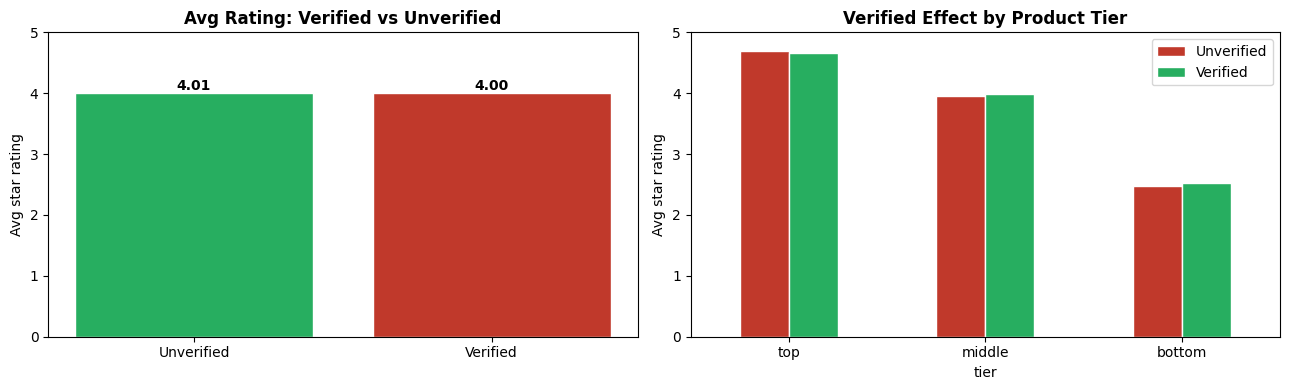

In [ ]:
# Cell A1c — Plot verified effect (corpus + by tier)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

v = verif_corpus.copy()
v["label"] = v["verified_purchase"].map({True: "Verified", False: "Unverified"})
axes[0].bar(v["label"], v["avg_rating"], color=["#27AE60", "#C0392B"], edgecolor="white")
axes[0].set_title("Avg Rating: Verified vs Unverified", fontweight="bold")
axes[0].set_ylabel("Avg star rating"); axes[0].set_ylim(0, 5)
for i, val in enumerate(v["avg_rating"]):
    axes[0].text(i, val + 0.05, f"{val:.2f}", ha="center", fontweight="bold")

t = verif_by_tier.copy()
t["label"] = t["verified_purchase"].map({True: "Verified", False: "Unverified"})
pivot = t.pivot(index="tier", columns="label", values="avg_rating").reindex(["top","middle","bottom"])
pivot.plot(kind="bar", ax=axes[1], color=["#C0392B", "#27AE60"], edgecolor="white", rot=0)
axes[1].set_title("Verified Effect by Product Tier", fontweight="bold")
axes[1].set_ylabel("Avg star rating"); axes[1].set_ylim(0, 5); axes[1].legend(title="")

plt.tight_layout()
plt.savefig("pa6_outputs/previews/verified_vs_unverified.png", dpi=150, bbox_inches="tight")
plt.show()

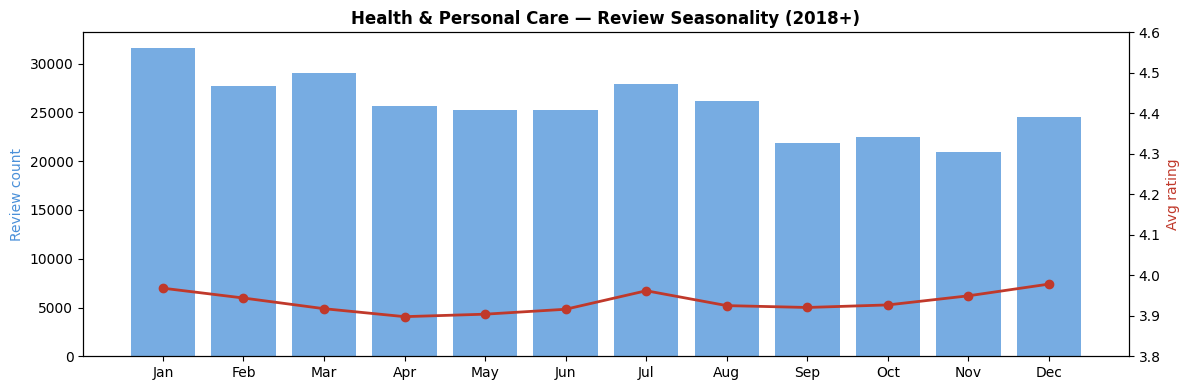

,review_month,review_count,avg_rating,verified_share
0,1,31628,3.968161,0.917257
1,2,27694,3.943887,0.912291
2,3,29088,3.917526,0.918179
3,4,25619,3.897849,0.920918
4,5,25209,3.903963,0.928200
5,6,25271,3.916149,0.921412
6,7,27876,3.961831,0.918855
7,8,26170,3.925105,0.918303
8,9,21912,3.920546,0.906900
9,10,22477,3.926814,0.901633


In [ ]:
# Cell A2 — Seasonality: review volume + rating by month-of-year
seasonal = (
    cleaned_reviews
    .filter(F.col("review_year") >= 2018)   # last 5+ years; older data is sparse
    .groupBy("review_month")
    .agg(
        F.count("*").alias("review_count"),
        F.avg("rating").alias("avg_rating"),
        F.avg(F.col("verified_purchase").cast("int")).alias("verified_share"),
    )
    .orderBy("review_month")
    .toPandas()
)

months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.bar(seasonal["review_month"], seasonal["review_count"], color="#4A90D9", alpha=0.75)
ax1.set_xticks(range(1, 13)); ax1.set_xticklabels(months)
ax1.set_ylabel("Review count", color="#4A90D9")
ax2 = ax1.twinx()
ax2.plot(seasonal["review_month"], seasonal["avg_rating"], color="#C0392B", marker="o", linewidth=2)
ax2.set_ylabel("Avg rating", color="#C0392B"); ax2.set_ylim(3.8, 4.6)
plt.title("Health & Personal Care — Review Seasonality (2018+)", fontweight="bold")
plt.tight_layout()
plt.savefig("pa6_outputs/previews/seasonality.png", dpi=150, bbox_inches="tight")
plt.show()
seasonal

In [ ]:
# Cell A3a — Top 20 vs bottom 20 (per main_category, min 50 reviews)
MIN_REVIEWS = 50
ranked = (
    product_review_stats
    .filter(F.col("review_count") >= MIN_REVIEWS)
    .withColumn("rank_top",
        F.row_number().over(
            Window.partitionBy("main_category")
                  .orderBy(F.desc("mean_review_rating"), F.desc("review_count"))))
    .withColumn("rank_bottom",
        F.row_number().over(
            Window.partitionBy("main_category")
                  .orderBy(F.asc("mean_review_rating"), F.desc("review_count"))))
)
top20    = ranked.filter(F.col("rank_top")    <= 20).orderBy("main_category", "rank_top")
bottom20 = ranked.filter(F.col("rank_bottom") <= 20).orderBy("main_category", "rank_bottom")

print(f"top 20 per category    rows: {top20.count():,}")
print(f"bottom 20 per category rows: {bottom20.count():,}")
top20.select("main_category","rank_top","clean_title","mean_review_rating",
             "review_count","verified_share").limit(20).toPandas()

top 20 per category    rows: 20
bottom 20 per category rows: 20


,main_category,rank_top,clean_title,mean_review_rating,review_count,verified_share
0,Health & Personal Care,1,Extra Large Heating pad for Back and Shoulder ...,5.000000,52,0.980769
1,Health & Personal Care,2,Rethilkry Plush Frog Hat Cap Frog Ears Costume...,4.981132,53,0.924528
2,Health & Personal Care,3,New DYKEM 80300 Steel Blue Layout Fluid Brush-...,4.967742,62,0.983871
3,Health & Personal Care,4,stripfast5000 Fire Bullets with K-CYTRO for Wo...,4.956140,114,0.991228
4,Health & Personal Care,5,JOHEXI 30pcs Gaming Themed Bracelets Party Favors,4.901961,51,1.000000
5,Health & Personal Care,6,Sleepfun 3D Sleep Mask Invisible Alar Deep Orb...,4.894737,114,0.947368
6,Health & Personal Care,7,Rutland Hearth & Grill Conditioning 8 Oz. (Pac...,4.889764,127,0.984252
7,Health & Personal Care,8,HYPR D3K2 Vitamin D3 + K2 (MK-7) Liquid Drops ...,4.878205,156,0.993590
8,Health & Personal Care,9,"Scrub Daddy, Scrub Mommy - Dual Sided Sponge &...",4.867925,106,0.971698
9,Health & Personal Care,10,"""Growing a Princess"" Sash & Flower Crown Kit -...",4.867257,113,0.991150


In [ ]:
# Cell A3b — Top vs bottom: corpus-level signal comparison
def summary(df, label):
    return (df.agg(
        F.avg("mean_review_rating").alias("avg_rating"),
        F.avg("verified_share").alias("avg_verified_share"),
        F.avg("review_count").alias("avg_review_count"),
        F.avg("repeat_reviewer_share").alias("avg_repeat_reviewer_share"),
        F.avg("mean_helpful_votes").alias("avg_helpful_votes"),
    ).withColumn("group", F.lit(label)))

top_vs_bot = summary(top20, "top20").union(summary(bottom20, "bottom20")).toPandas()
top_vs_bot

,avg_rating,avg_verified_share,avg_review_count,avg_repeat_reviewer_share,avg_helpful_votes,group
0,4.885511,0.951027,115.65,0.000000,0.545974,top20
1,1.722025,0.948647,94.45,0.000459,1.647510,bottom20


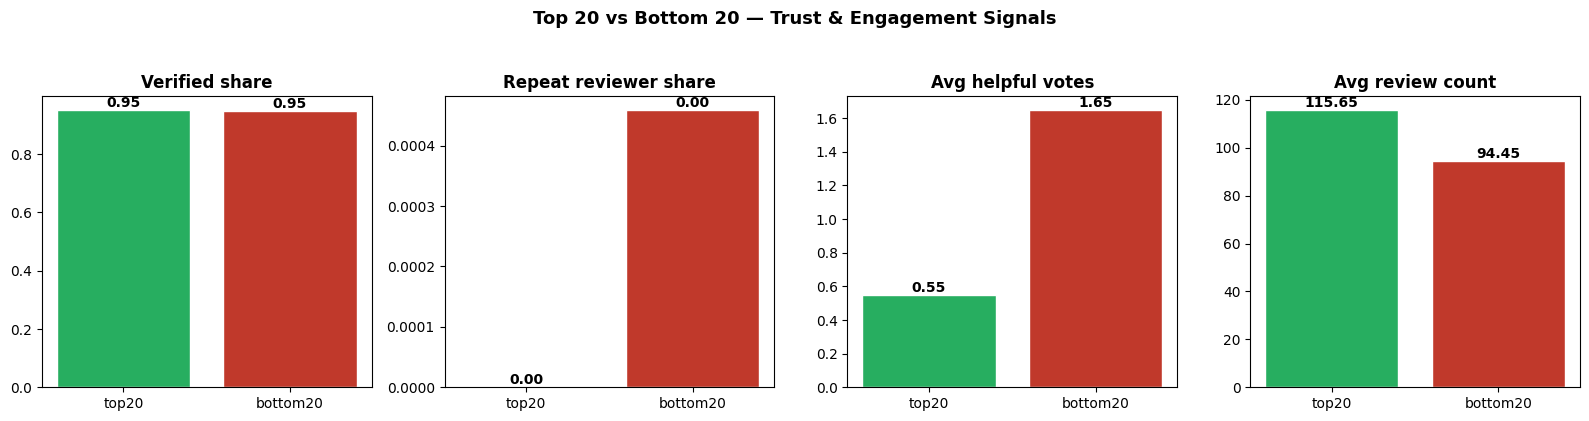

In [ ]:
# Cell A3c — Top vs bottom on 4 trust/engagement metrics
metrics = ["avg_verified_share", "avg_repeat_reviewer_share",
           "avg_helpful_votes", "avg_review_count"]
labels  = ["Verified share", "Repeat reviewer share",
           "Avg helpful votes", "Avg review count"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, m, lbl in zip(axes, metrics, labels):
    vals = top_vs_bot.set_index("group")[m].reindex(["top20","bottom20"])
    ax.bar(vals.index, vals.values, color=["#27AE60","#C0392B"], edgecolor="white")
    ax.set_title(lbl, fontweight="bold")
    for i, v in enumerate(vals.values):
        ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontweight="bold")
plt.suptitle("Top 20 vs Bottom 20 — Trust & Engagement Signals",
             fontsize=13, fontweight="bold", y=1.04)
plt.tight_layout()
plt.savefig("pa6_outputs/previews/top_vs_bottom.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Cell A4a — Trust + repurchase keyword lexicon (Health-specific)
TRUST_POS = [
    r"\bworks?\b", r"\bworked\b", r"\beffective\b", r"\bhelps?\b", r"\bhelped\b",
    r"\brelief\b", r"\brelieves?\b", r"\bnoticeable\b", r"\bresults?\b",
    r"\brecommend(?:ed)?\b", r"\bdoctor\b", r"\bsafe\b", r"\bquality\b", r"\bworth\b",
]
TRUST_NEG = [
    r"\bdoesn'?t work\b", r"\bdid(?:n'?t| not) work\b",
    r"\bwaste of money\b", r"\buseless\b", r"\bineffective\b",
    r"\bno difference\b", r"\bno effect\b", r"\bno results?\b",
    r"\bside effects?\b", r"\bmade me sick\b", r"\bbroke out\b",
    r"\bfake\b", r"\bcounterfeit\b", r"\bmisleading\b",
]
REPURCHASE = [
    r"\bbuy(?:ing)? again\b", r"\bbought again\b", r"\brepurchase\b",
    r"\bsubscribe\b", r"\bsecond bottle\b", r"\bsecond order\b",
    r"\bran out\b", r"\bre[- ]?order(?:ed)?\b", r"\bstocking up\b",
    r"\bmy go[- ]?to\b", r"\brefill\b",
]

def any_match(col, patterns):
    expr = F.lit(False)
    for p in patterns:
        expr = expr | F.col(col).rlike(f"(?i){p}")
    return expr

flagged = (
    cleaned_reviews
    .withColumn("has_trust_pos",  any_match("clean_review_text", TRUST_POS))
    .withColumn("has_trust_neg",  any_match("clean_review_text", TRUST_NEG))
    .withColumn("has_repurchase", any_match("clean_review_text", REPURCHASE))
)
# this triggers the full text scan — expect a few minutes on 20M rows
flagged.select(
    F.avg(F.col("has_trust_pos").cast("int")).alias("trust_pos_pct"),
    F.avg(F.col("has_trust_neg").cast("int")).alias("trust_neg_pct"),
    F.avg(F.col("has_repurchase").cast("int")).alias("repurchase_pct"),
).show()

+-----------------+--------------------+--------------------+
|    trust_pos_pct|       trust_neg_pct|      repurchase_pct|
+-----------------+--------------------+--------------------+
|0.352436655146322|0.030180576289903678|0.016194605206650444|
+-----------------+--------------------+--------------------+



In [ ]:
# Cell A4b — Aggregate keyword signals to product level
keyword_signal = (
    flagged.groupBy("parent_asin")
    .agg(
        F.avg(F.col("has_trust_pos").cast("int")).alias("trust_pos_share"),
        F.avg(F.col("has_trust_neg").cast("int")).alias("trust_neg_share"),
        F.avg(F.col("has_repurchase").cast("int")).alias("repurchase_text_share"),
    )
)
product_with_keywords = (
    product_review_stats
    .join(keyword_signal, on="parent_asin", how="left")
    .filter(F.col("review_count") >= 50)
)
print(f"products with keyword signal: {product_with_keywords.count():,}")

products with keyword signal: 1,399


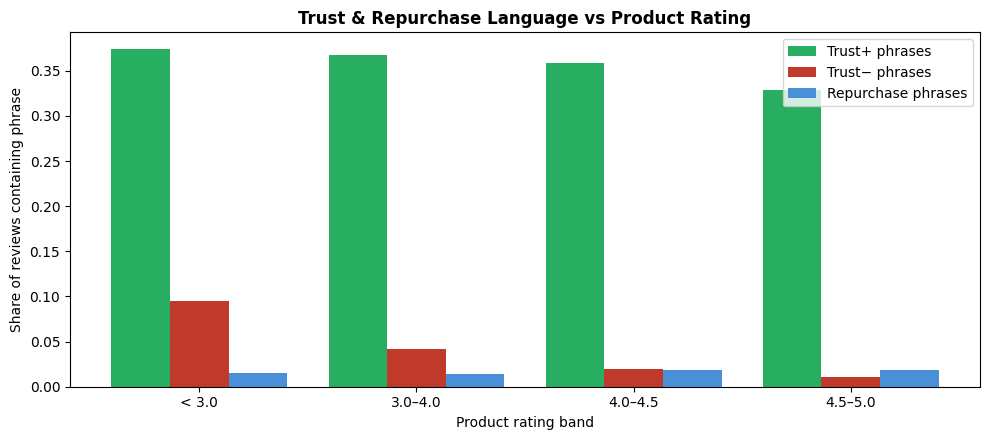

,product_count,trust_pos_share,trust_neg_share,repurchase_text_share
rating_band,,,,
< 3.0,102,0.374009,0.094600,0.015131
3.0–4.0,464,0.367305,0.042303,0.014001
4.0–4.5,517,0.358532,0.020186,0.018109
4.5–5.0,316,0.328306,0.010576,0.018780


In [ ]:
# Cell A4c — Does keyword signal track product quality?
quality_check = (
    product_with_keywords
    .withColumn("rating_band",
        F.when(F.col("mean_review_rating") >= 4.5, "4.5–5.0")
         .when(F.col("mean_review_rating") >= 4.0, "4.0–4.5")
         .when(F.col("mean_review_rating") >= 3.0, "3.0–4.0")
         .otherwise("< 3.0"))
    .groupBy("rating_band")
    .agg(
        F.count("*").alias("product_count"),
        F.avg("trust_pos_share").alias("trust_pos_share"),
        F.avg("trust_neg_share").alias("trust_neg_share"),
        F.avg("repurchase_text_share").alias("repurchase_text_share"),
    )
    .toPandas()
)
order = ["< 3.0", "3.0–4.0", "4.0–4.5", "4.5–5.0"]
q = quality_check.set_index("rating_band").reindex(order)

fig, ax = plt.subplots(figsize=(10, 4.5))
x = range(len(order)); w = 0.27
ax.bar([i - w for i in x], q["trust_pos_share"],       w, label="Trust+ phrases",     color="#27AE60")
ax.bar(x,                   q["trust_neg_share"],       w, label="Trust− phrases",     color="#C0392B")
ax.bar([i + w for i in x],  q["repurchase_text_share"], w, label="Repurchase phrases", color="#4A90D9")
ax.set_xticks(x); ax.set_xticklabels(order)
ax.set_xlabel("Product rating band"); ax.set_ylabel("Share of reviews containing phrase")
ax.set_title("Trust & Repurchase Language vs Product Rating", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("pa6_outputs/previews/keyword_by_rating_band.png", dpi=150, bbox_inches="tight")
plt.show()
q

In [ ]:
# Cell A5a — Repurchase: behavioral signal (user × product repeats)
user_prod_counts = (
    cleaned_reviews
    .groupBy("user_id", "parent_asin")
    .agg(F.count("*").alias("times_reviewed"))
)
total_pairs  = user_prod_counts.count()
repeat_count = user_prod_counts.filter(F.col("times_reviewed") > 1).count()
print(f"unique (user, product) pairs : {total_pairs:,}")
print(f"repeat pairs (>1 review)     : {repeat_count:,}")
print(f"behavioral repeat rate       : {100*repeat_count/total_pairs:.2f}%")

unique (user, product) pairs : 488,188
repeat pairs (>1 review)     : 709
behavioral repeat rate       : 0.15%


In [ ]:
# Cell A6 — Save all analytical outputs to GCS for the report
verif_corpus.to_csv("pa6_outputs/analysis/verified_corpus.csv", index=False)
verif_by_tier.to_csv("pa6_outputs/analysis/verified_by_tier.csv", index=False)
seasonal.to_csv("pa6_outputs/analysis/seasonality.csv", index=False)
top_vs_bot.to_csv("pa6_outputs/analysis/top_vs_bottom_summary.csv", index=False)
quality_check.to_csv("pa6_outputs/analysis/keyword_by_rating_band.csv", index=False)

top20.write.mode("overwrite").parquet("pa6_outputs/analysis/top20_per_category")
bottom20.write.mode("overwrite").parquet("pa6_outputs/analysis/bottom20_per_category")

!gsutil -m rsync -r pa6_outputs/analysis $BUCKET_URI/pa6_outputs/analysis
!gsutil -m cp pa6_outputs/previews/*.png $BUCKET_URI/pa6_outputs/previews/
print("Analysis complete.")

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.

both the source and destination. Your crcmod installation isn't using the
module's C extension, so checksumming will run very slowly. If this is your
first rsync since updating gsutil, this rsync can take significantly longer than
usual. For help installing the extension, please see "gsutil help crcmod".

Building synchronization state...
Starting synchronization...
Copying file://pa6_outputs/analysis/keyword_by_rating_band.csv [Content-Type=text/csv]...
Copying file://pa6_outputs/analysis/top20_per_category/part-00000-a0179476-8930-42be-a079-8f372aabed3a-c000.snappy.parquet [Content-Type=application/octet-stream]...
Copying file://pa6_outputs/analysis/top20_per_category/.part-00000-a0179476-8930-42be-a079-8f372aabed3a-c000.snappy